Continuous ISA decomposition. Instead of a fixed set of fractional gates, a continuous ISA treats gate power as a free variable: any $G^k$ for $k \in [k_{\text{lb}}, 1]$ is available. The LP solves over continuous strengths instead of enumerating discrete sentences.

Requires the CPLEX backend: `pip install gulps[cplex]`

In [1]:
# !pip install -e .[cplex]

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import lovelyplots
from qiskit.circuit.library import RXXGate, iSwapGate, SwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from tqdm import tqdm, trange

from gulps import GulpsDecomposer, GateInvariants, logger
from gulps.core.isa import ContinuousISA, DiscreteISA
from gulps.core.coverage import compute_coverage_statistics
from gulps.config import GulpsConfig
from gulps.viz.invariant_viz import plot_decomposition
from gulps.viz.report_viz import compare_continuous_discrete, report_benchmark_results
from gulps.comparisons.isa_library.fsim import fsim

Compare a continuous ISA (arbitrary gate powers) against a discrete ISA (fixed fractional powers). The `single_qubit_cost` parameter models the overhead from local unitary layers — try different base gates (RXX, iSwap, SWAP, fSim) to see how choice affects costs.

In [3]:
single_qubit_cost = 0.1
base_gate = RXXGate(theta=np.pi / 2)
# base_gate = iSwapGate()
# base_gate = SwapGate()
# base_gate = fsim(np.pi / 2, np.pi / 6)

continuous_isa = ContinuousISA.from_base_gate(
    base_gate, single_qubit_cost=single_qubit_cost
)
continuous_decomposer = GulpsDecomposer(
    isa=continuous_isa, config_options=GulpsConfig(flag_duration=0.0)
)

In [4]:
_gates = [
    (base_gate.power(1 / 2), 1 / 2, "sqrt2"),
    # (base_gate.power(1 / 3), 1 / 3, "sqrt3"),
    # (base_gate.power(1 / 4), 1 / 4, "sqrt4"),
    # (base_gate.power(1 / 5), 1 / 5, "sqrt5"),
    # (base_gate.power(1 / 6), 1 / 6, "sqrt6"),
]
gate_set, costs, names = zip(*_gates)
discrete_isa = DiscreteISA(gate_set, costs, names, single_qubit_cost=single_qubit_cost)
discrete_decomposer = GulpsDecomposer(isa=discrete_isa)

Benchmark: 1000 Haar-random unitaries with the continuous decomposer. Unlike the discrete case, here the `lp_sentence` determination will dominate the runtime.

In [5]:
logger.setLevel("INFO")
N = 1_000

fidelities = []
all_timings = []
failures = 0

for idx in trange(N, desc="Decomposing random unitaries"):
    u = random_unitary(4, seed=idx)
    try:
        fid = average_gate_fidelity(u, Operator(continuous_decomposer(u)))
        if fid < 1 - 1e-8:
            raise ValueError(f"Fidelity too low: {fid:.8f}")
        fidelities.append(fid)
        all_timings.append(continuous_decomposer.last_timing)
    except Exception as e:
        print(f"[WARN] Failed on unitary {idx}: {e}")
        failures += 1

Decomposing random unitaries:   0%|          | 0/1000 [00:00<?, ?it/s]

Decomposing random unitaries: 100%|██████████| 1000/1000 [00:52<00:00, 18.93it/s]


Benchmark: 1000/1000 successful (0 failures)
Fidelity: median=1.0000000000, min=1.0000000000
Avg time: 51066.3 us/decomposition


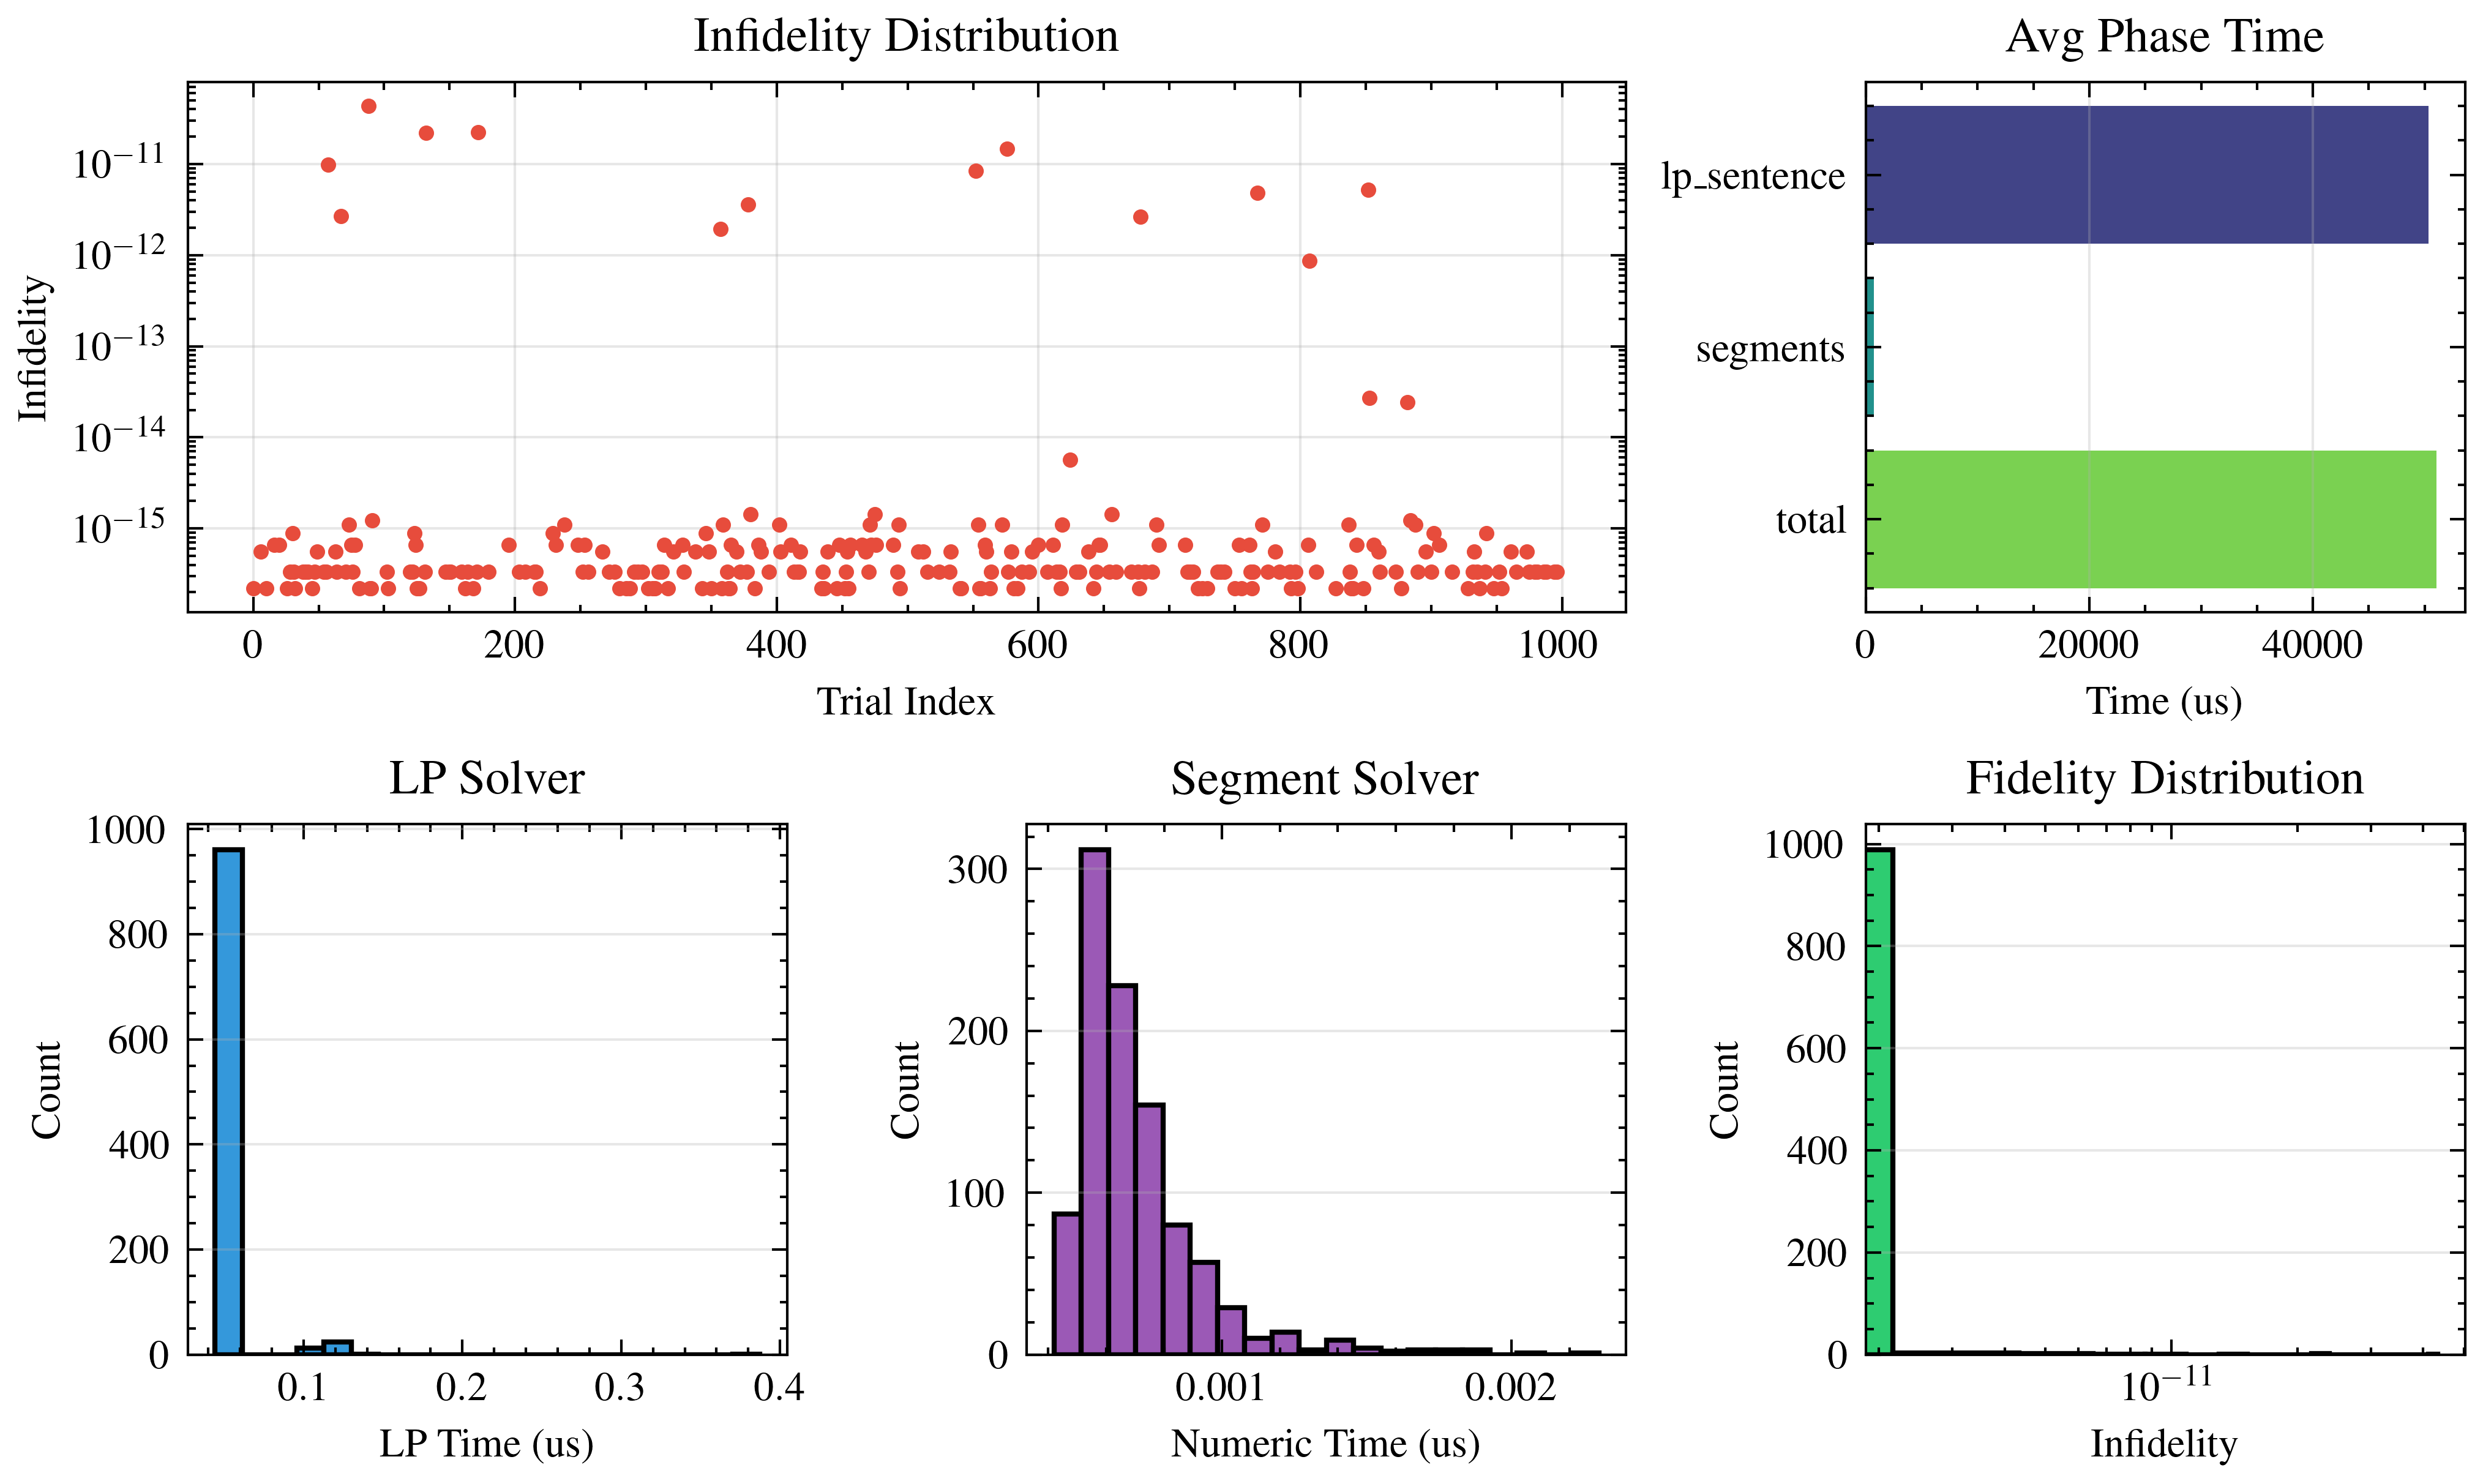

In [6]:
report_benchmark_results(fidelities, all_timings, continuous_decomposer, N, failures)

Side-by-side animated trajectories: continuous vs discrete decomposition of the same targets.

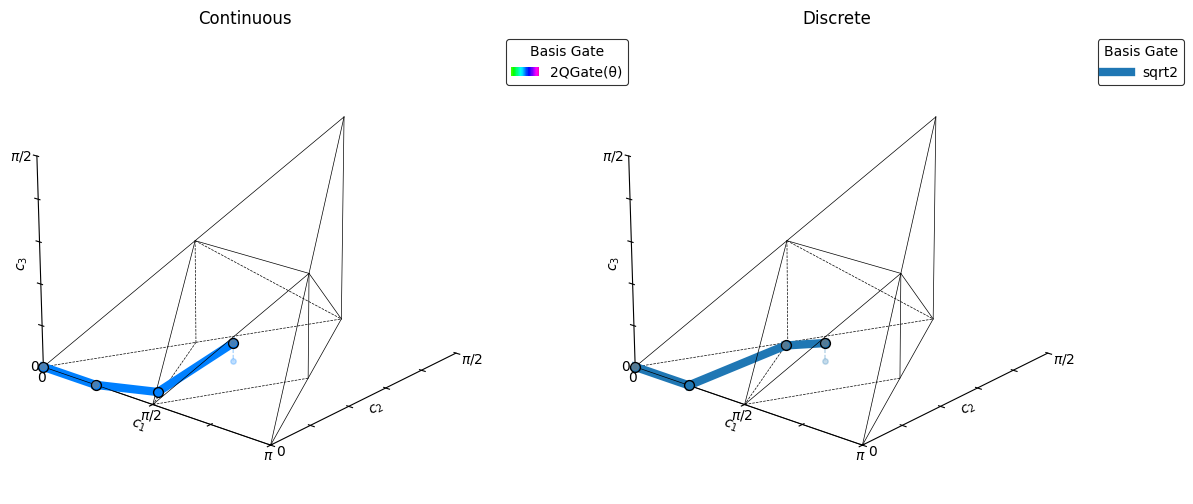

In [7]:
from IPython.display import display, clear_output
import time as _time

for _i in range(20):
    clear_output(wait=True)
    target = GateInvariants.from_unitary(random_unitary(4, seed=_i + 200))

    r_cts = continuous_decomposer._best_decomposition(target)
    r_disc = discrete_decomposer._best_decomposition(target)

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection="3d")
    plot_decomposition(
        r_cts.intermediates, r_cts.sentence, continuous_isa, r_cts.parameters, ax=ax1
    )
    ax1.set_title("Continuous")

    ax2 = fig.add_subplot(122, projection="3d")
    plot_decomposition(
        r_disc.intermediates, r_disc.sentence, discrete_isa, r_disc.parameters, ax=ax2
    )
    ax2.set_title("Discrete")

    display(fig)
    plt.close(fig)
    _time.sleep(0.15)

---

Cost and depth analysis. As the basis gate power shrinks, more gates are needed to reach arbitrary targets. The continuous ISA (dashed) represents the (estimated via sampling) theoretical lower bound.

In [8]:
continuous_depth = []
continuous_costs = []

for idx in tqdm(range(N), desc="Collecting continuous ISA statistics"):
    target = GateInvariants.from_unitary(random_unitary(dims=4, seed=idx))
    sol = continuous_decomposer._best_decomposition(target)
    continuous_costs.append(sol.cost)
    continuous_depth.append(len(sol.sentence))

Sweep over single basis gate powers to see how depth and cost change. Without `single_qubit_cost`, weaker gates look artificially cheap because depth is free.

In [9]:
# reverse into expected cost had the single_qubit_cost been 0.0
expected_costs = sum(continuous_costs) / len(continuous_costs)
expected_depth = sum(continuous_depth) / len(continuous_depth)
baseline_cost = expected_costs - (expected_depth + 1) * continuous_isa.single_qubit_cost

# Sweep over fractional powers of base gate
x = np.linspace(0.2, 1.0, 9)
results = []

for power in tqdm(x, desc="Computing coverage"):
    _isa = DiscreteISA(
        gate_set=[base_gate.power(power)],
        costs=[power],
        names=[f"g^{power:.2f}"],
        precompute_polytopes=True,
    )
    stats = compute_coverage_statistics(_isa.coverage_set, chatty=False)
    results.append(
        {
            "power": power,
            "expected_cost_base": stats["expected_cost"],
            "expected_depth": stats["expected_depth"],
        }
    )

# Extract data
x = np.array([r["power"] for r in results])
cost_base = np.array([r["expected_cost_base"] for r in results])
depth = np.array([r["expected_depth"] for r in results])

# Compute cost with various single_qubit_cost values
single_qubit_costs = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]
cost_curves = {sq: cost_base + (depth + 1) * sq for sq in single_qubit_costs}

# Compute continuous ISA costs for each single_qubit_cost
continuous_costs_by_sq = {
    sq: baseline_cost + (expected_depth + 1) * sq for sq in single_qubit_costs
}

Computing coverage:   0%|          | 0/9 [00:00<?, ?it/s]

Computing coverage: 100%|██████████| 9/9 [00:17<00:00,  1.97s/it]


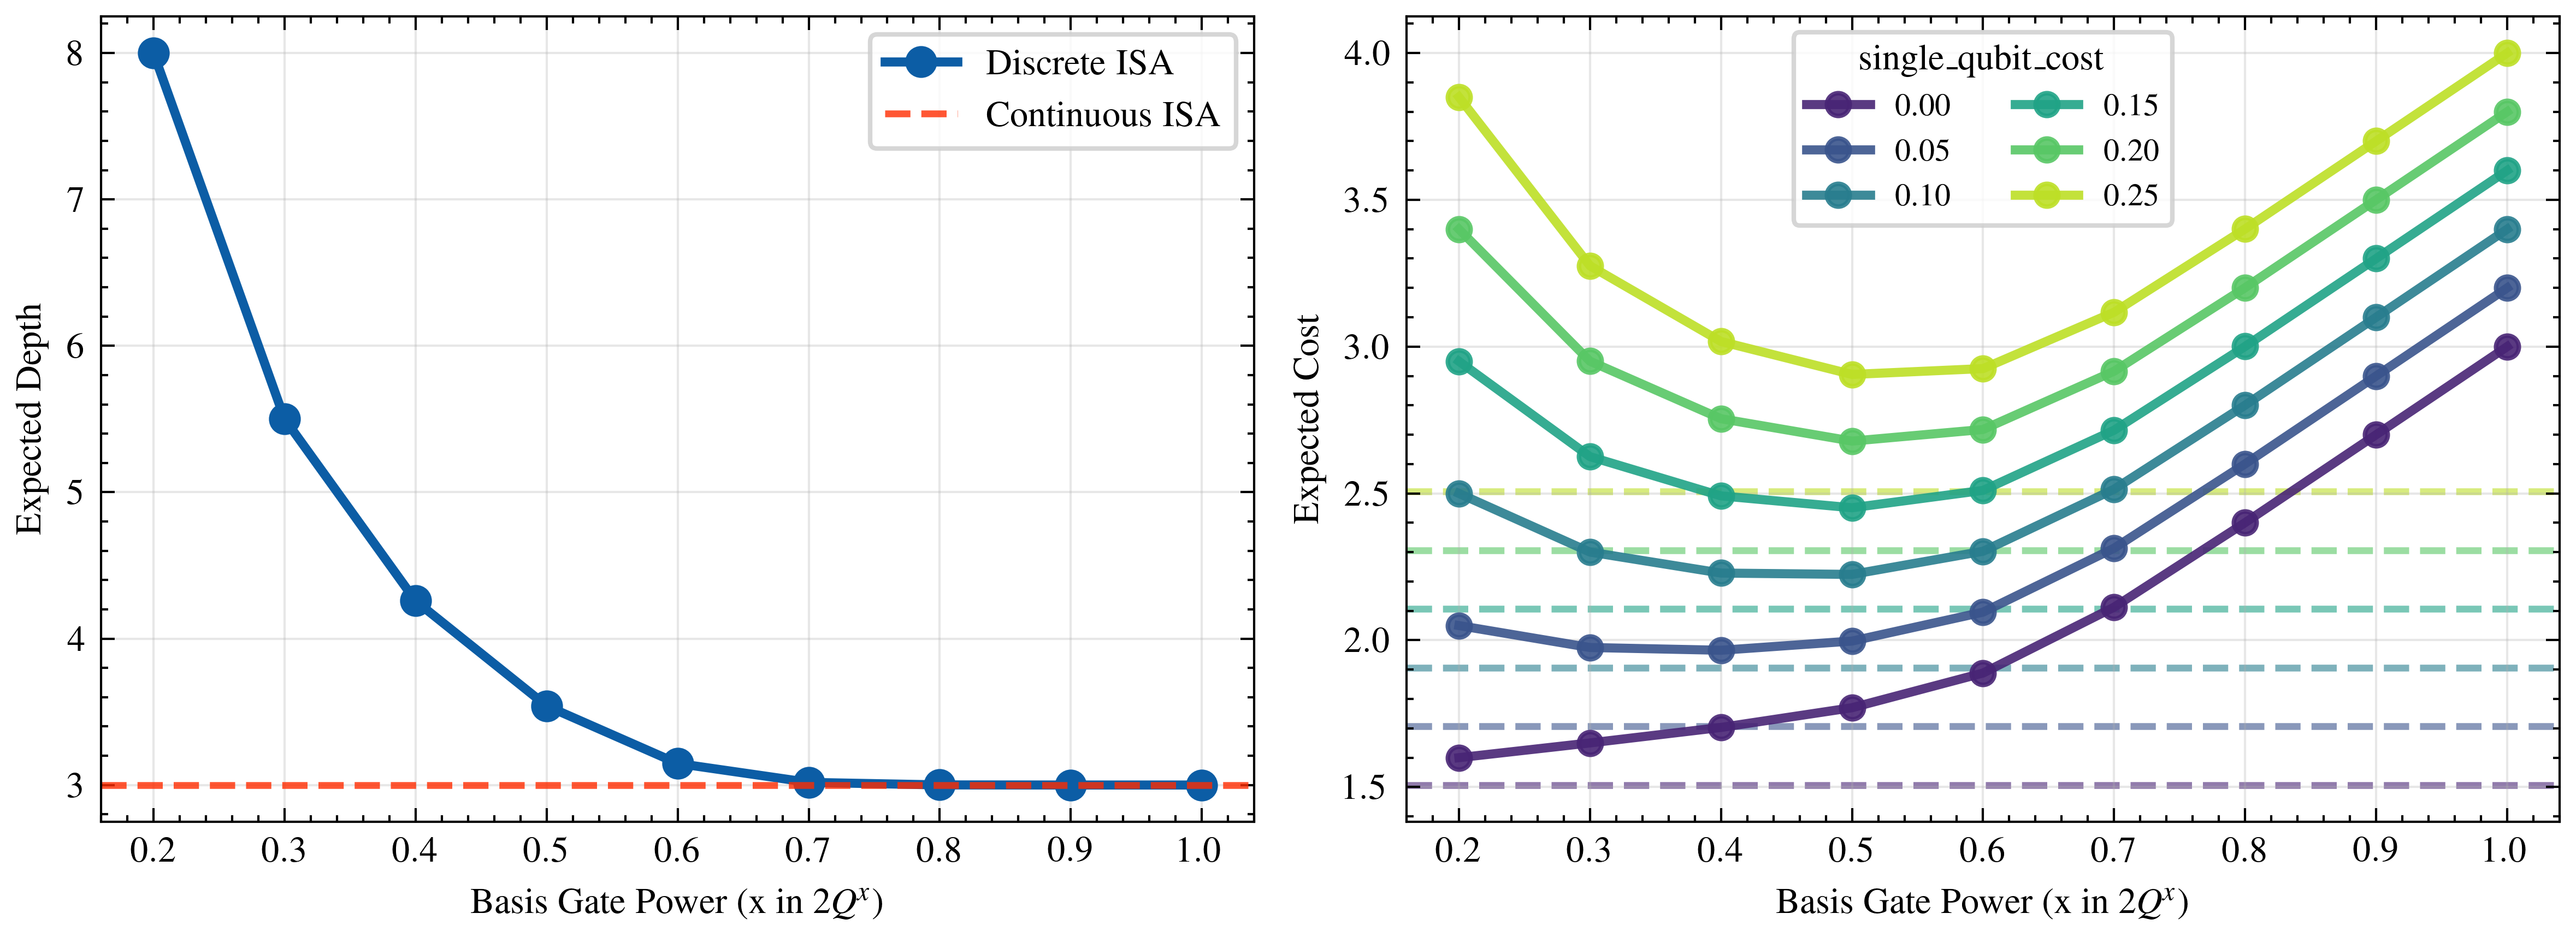

In [10]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0))

    # Left: Expected depth vs gate power
    axes[0].plot(x, depth, "-o", linewidth=2, markersize=6, label="Discrete ISA")
    if expected_depth is not None:
        axes[0].axhline(
            y=expected_depth,
            color="C3",
            linestyle="--",
            linewidth=1.5,
            label="Continuous ISA",
            alpha=0.8,
        )
    axes[0].set_xlabel(rf"Basis Gate Power (x in $2Q^x$)")
    axes[0].set_ylabel("Expected Depth")
    axes[0].legend(fontsize=8, loc="best", frameon=True)
    axes[0].grid(True, alpha=0.3)

    # Right: Expected cost vs gate power for different single_qubit_cost values
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(single_qubit_costs)))
    for i, sq_cost in enumerate(single_qubit_costs):
        axes[1].plot(
            x,
            cost_curves[sq_cost],
            "-o",
            linewidth=2,
            markersize=5,
            label=f"{sq_cost:.2f}",
            color=colors[i],
            alpha=0.9,
        )
        axes[1].axhline(
            y=continuous_costs_by_sq[sq_cost],
            color=colors[i],
            linestyle="--",
            linewidth=1.5,
            alpha=0.6,
            zorder=0,
        )
    axes[1].set_xlabel(rf"Basis Gate Power (x in $2Q^x$)")
    axes[1].set_ylabel("Expected Cost")
    axes[1].legend(
        title="single\\_qubit\\_cost", fontsize=7, loc="best", frameon=True, ncol=2
    )
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---

Two-gate synergy. Real hardware might calibrate two entangling gates. Sweeping all pairs of basis gate powers to see if the optimal pair is synergistic. This sweep is expensive because it is calculating expected costs exactly via Haar-weighted integrals over monodromy polytopes; rather than via random sampling.

In [11]:
single_qubit_cost_fixed = continuous_isa.single_qubit_cost
powers_2d = np.linspace(0.2, 1.0, 9)
n_powers = len(powers_2d)

cost_matrix = np.full((n_powers, n_powers), np.nan)
depth_matrix = np.full((n_powers, n_powers), np.nan)

continuous_ref = sum(continuous_costs) / len(continuous_costs)

for i in trange(n_powers, desc="2D basis gate sweep"):
    for j in range(i, n_powers):
        p1, p2 = powers_2d[i], powers_2d[j]
        try:
            if i == j:
                isa_spec = [(base_gate.power(p1), p1, f"g^{p1:.2f}")]
            else:
                isa_spec = [
                    (base_gate.power(p1), p1, f"g^{p1:.2f}"),
                    (base_gate.power(p2), p2, f"g^{p2:.2f}"),
                ]
            gs, cs, ns = zip(*isa_spec)
            _isa = DiscreteISA(
                gs,
                cs,
                ns,
                precompute_polytopes=True,
                single_qubit_cost=single_qubit_cost_fixed,
            )
            stats = compute_coverage_statistics(_isa.coverage_set, chatty=False)
            cost_matrix[i, j] = stats["expected_cost"]
            cost_matrix[j, i] = stats["expected_cost"]
            depth_matrix[i, j] = stats["expected_depth"]
            depth_matrix[j, i] = stats["expected_depth"]
        except Exception as e:
            print(f"  [WARN] ({p1:.2f}, {p2:.2f}): {e}")

best_idx = np.unravel_index(np.nanargmin(cost_matrix), cost_matrix.shape)
best_p1, best_p2 = powers_2d[best_idx[0]], powers_2d[best_idx[1]]
best_cost = cost_matrix[best_idx]
best_single_idx = np.nanargmin(np.diag(cost_matrix))
best_single_cost = np.diag(cost_matrix)[best_single_idx]

print(f"\nContinuous ISA cost:          {continuous_ref:.4f}")
print(
    f"Best single gate (x={powers_2d[best_single_idx]:.2f}):   {best_single_cost:.4f}  ({(best_single_cost / continuous_ref - 1) * 100:+.1f}%)"
)
print(
    f"Best pair ({best_p1:.2f}, {best_p2:.2f}):        {best_cost:.4f}  ({(best_cost / continuous_ref - 1) * 100:+.1f}%)"
)

2D basis gate sweep:   0%|          | 0/9 [00:00<?, ?it/s]

2D basis gate sweep: 100%|██████████| 9/9 [05:02<00:00, 33.66s/it]


Continuous ISA cost:          1.9068
Best single gate (x=0.50):   2.2242  (+16.6%)
Best pair (0.40, 0.50):        2.0189  (+5.9%)


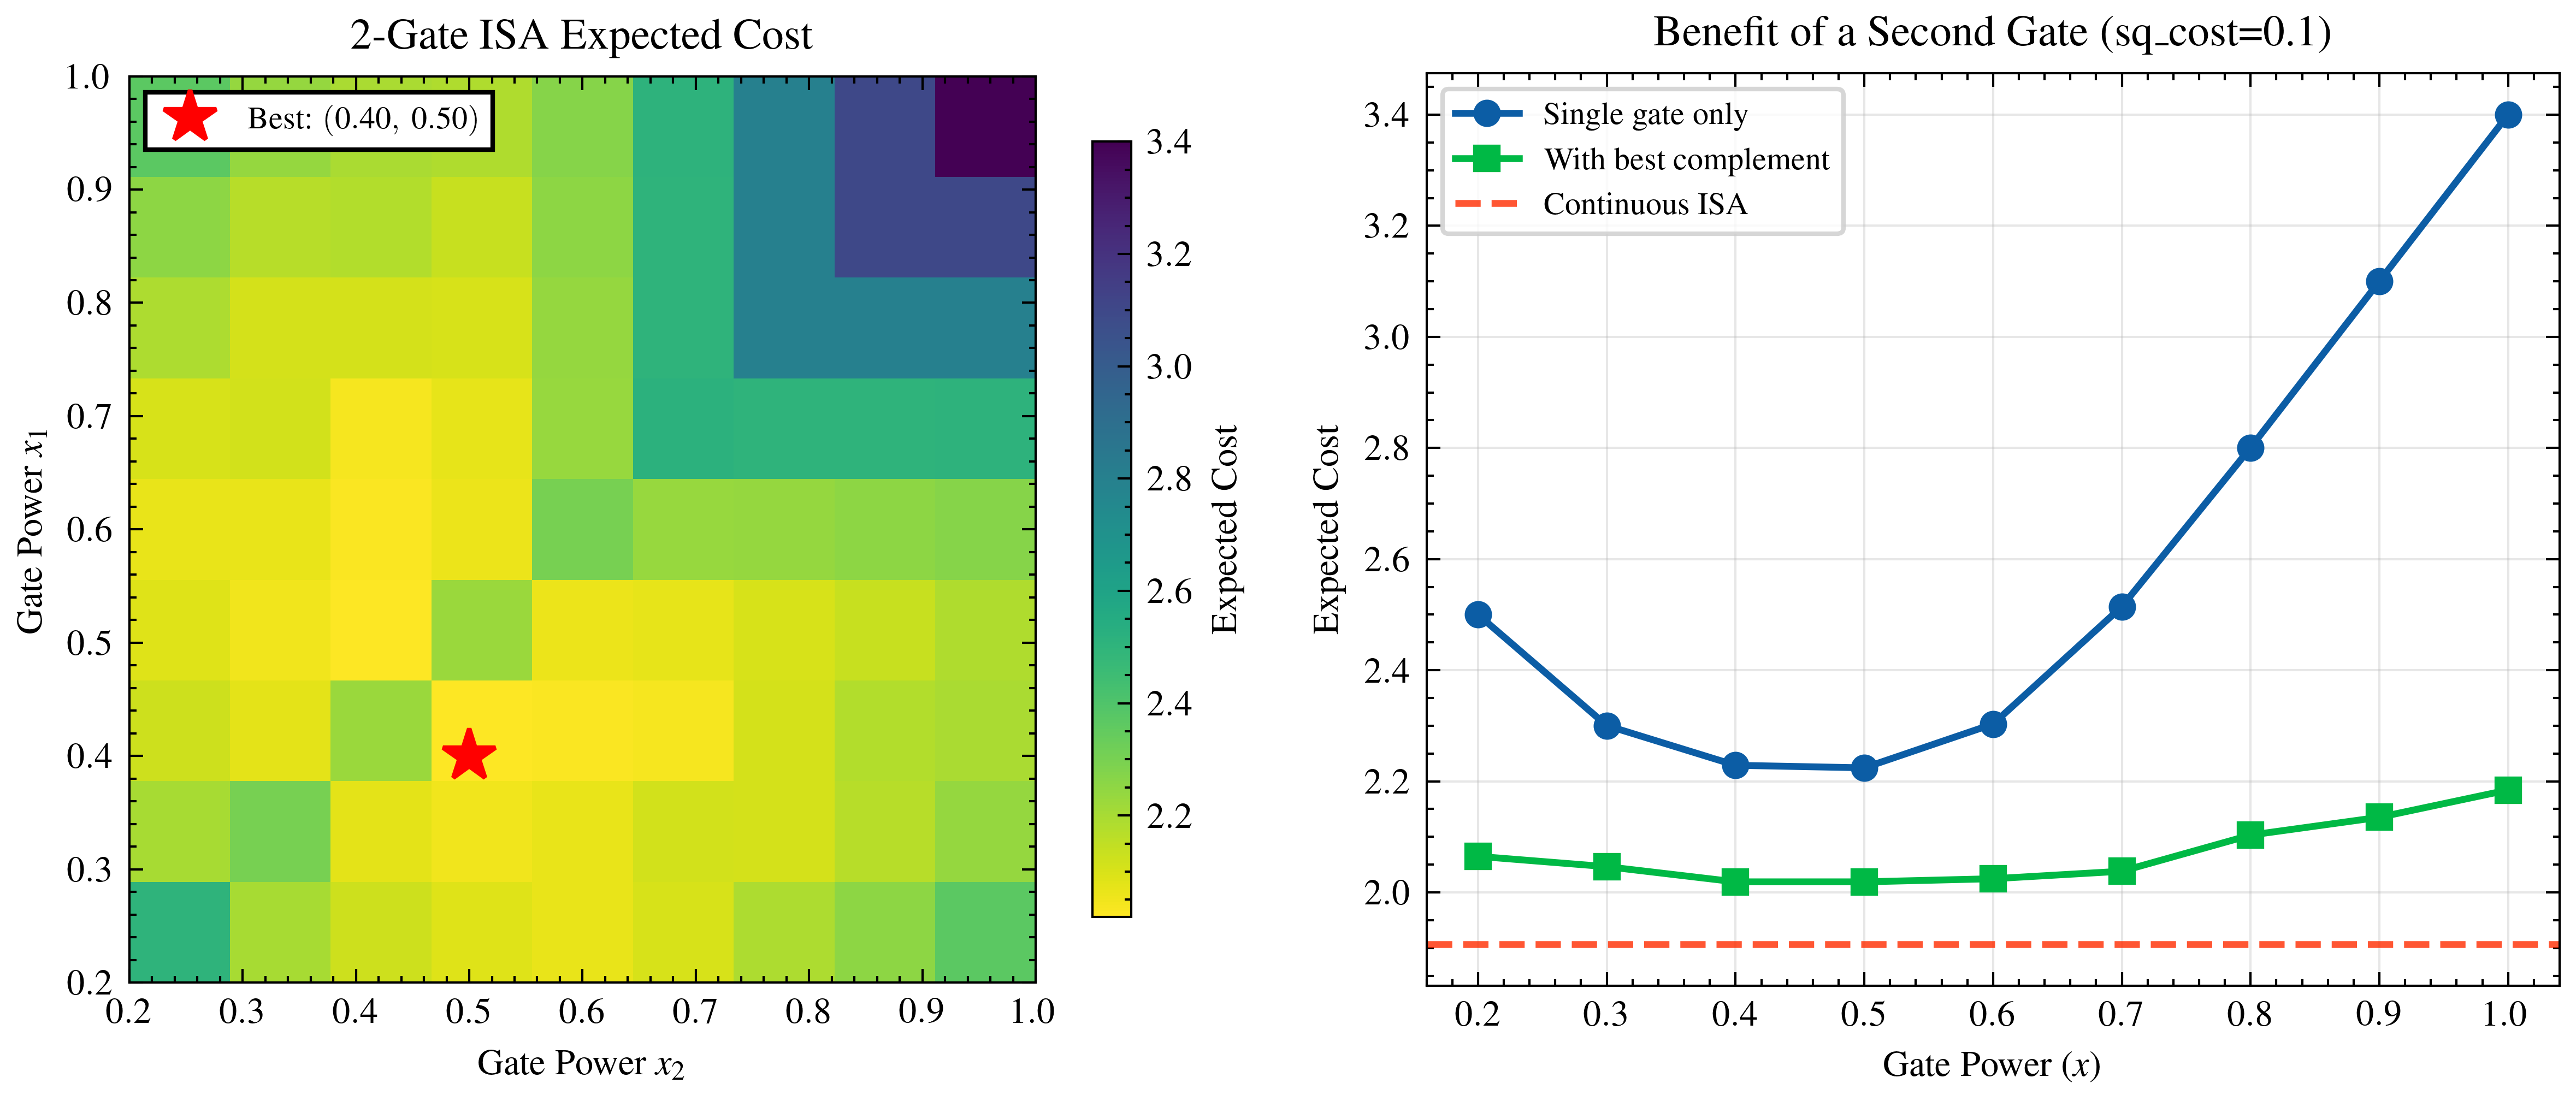

In [12]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.5))

    extent = [powers_2d[0], powers_2d[-1], powers_2d[0], powers_2d[-1]]
    im = axes[0].imshow(
        cost_matrix,
        origin="lower",
        aspect="equal",
        extent=extent,
        cmap="viridis_r",
    )
    X, Y = np.meshgrid(powers_2d, powers_2d)
    axes[0].contour(
        X,
        Y,
        cost_matrix,
        levels=[continuous_ref],
        colors="red",
        linestyles="--",
        linewidths=1.0,
    )
    axes[0].plot(
        best_p2,
        best_p1,
        "r*",
        markersize=12,
        label=f"Best: $({best_p1:.2f},\\ {best_p2:.2f})$",
    )
    axes[0].set_xlabel(rf"Gate Power $x_2$")
    axes[0].set_ylabel(rf"Gate Power $x_1$")
    axes[0].set_title("2-Gate ISA Expected Cost")
    axes[0].legend(
        fontsize=7,
        loc="upper left",
        frameon=True,
        framealpha=1.0,
        edgecolor="black",
        fancybox=False,
    )
    cbar = fig.colorbar(im, ax=axes[0], shrink=0.85)
    cbar.set_label("Expected Cost")

    single_costs = np.diag(cost_matrix)
    best_complement_costs = np.nanmin(cost_matrix, axis=1)

    axes[1].plot(
        powers_2d,
        single_costs,
        "-o",
        markersize=5,
        label="Single gate only",
        linewidth=1.5,
    )
    axes[1].plot(
        powers_2d,
        best_complement_costs,
        "-s",
        markersize=5,
        label="With best complement",
        linewidth=1.5,
    )
    axes[1].axhline(
        y=continuous_ref,
        color="C3",
        linestyle="--",
        linewidth=1.5,
        label="Continuous ISA",
        alpha=0.8,
    )
    axes[1].set_xlabel(rf"Gate Power ($x$)")
    axes[1].set_ylabel("Expected Cost")
    axes[1].set_title(f"Benefit of a Second Gate (sq\\_cost={single_qubit_cost_fixed})")
    axes[1].legend(fontsize=7, loc="best", frameon=True)
    axes[1].grid(True, alpha=0.3)
    axes[1].margins(y=0.05)

    plt.tight_layout()
    plt.show()